# Laboratorio 8

In [30]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
import pyreadr
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

In [31]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [32]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [33]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

In [34]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [35]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [36]:
pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [37]:
# variables importantes
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating"
]]

y = df["price_category"]

# imputar
from sklearn.impute import SimpleImputer
X = SimpleImputer(strategy="mean").fit_transform(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab8-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [38]:
# escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Variable Respuesta

Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:
 - Económico
 - Intermedio
- Caro

### 4. Modelos SVM y 5. Predicción con modelos entrenados

In [39]:
# RBF
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6163766722042494


In [40]:
# LINEAL
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)

y_pred_lin = svm_linear.predict(X_test_scaled)
acc_lin = accuracy_score(y_test, y_pred_lin)

print("Accuracy:", acc_lin)


Accuracy: 0.6058406924892892


In [41]:
# POLINOMIAL
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, y_pred_poly)

print("Accuracy:", acc_poly)


Accuracy: 0.578517093643438


In [42]:
# Tuneo de gamma para el kernel RBF
gamma_values = [0.01, 0.1, 1, 'scale']

acc_gamma = []
for g in gamma_values:
    svm_g = SVC(kernel='rbf', C=1, gamma=g)
    svm_g.fit(X_train_scaled, y_train)
    acc_gamma.append(accuracy_score(y_test, svm_g.predict(X_test_scaled)))

for g, a in zip(gamma_values, acc_gamma):
    print(f"gamma={g}: accuracy={a:.4f}")

gamma=0.01: accuracy=0.6068
gamma=0.1: accuracy=0.6139
gamma=1: accuracy=0.6258
gamma=scale: accuracy=0.6164


### 6. Matrices de confusión

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

# Modelo 1 
cm_rbf = confusion_matrix(y_test, y_pred)

# Modelo 2 
cm_lin = confusion_matrix(y_test, y_pred_lin)

# Modelo 3 
cm_poly = confusion_matrix(y_test, y_pred_poly)

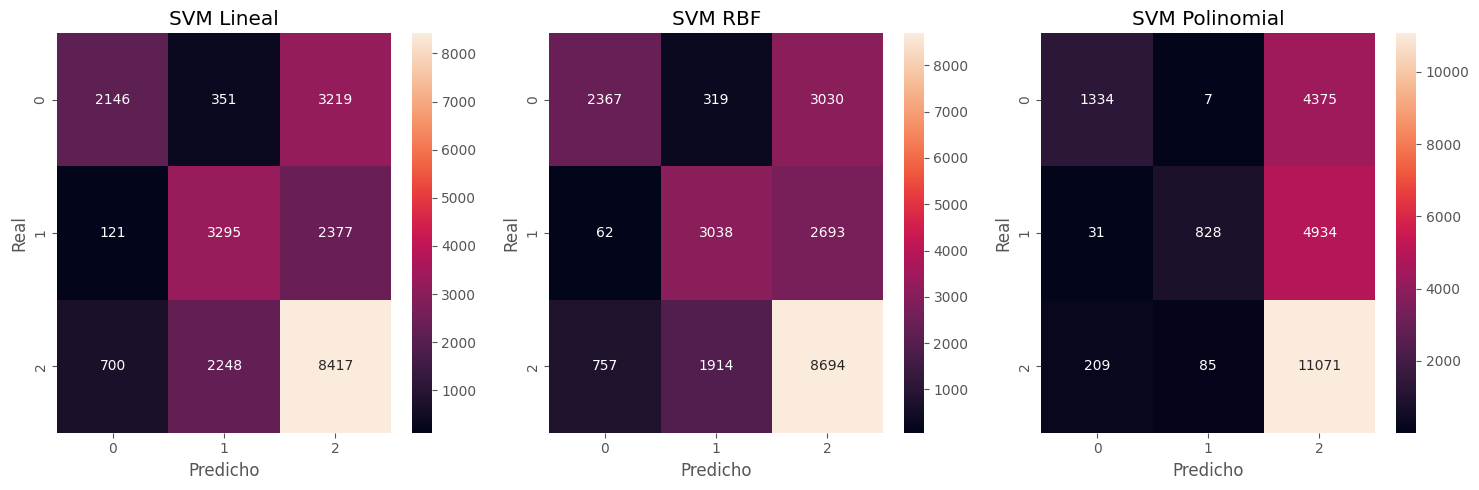

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(cm_lin, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("SVM Lineal")

sns.heatmap(cm_rbf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("SVM RBF")

sns.heatmap(cm_poly, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("SVM Polinomial")

for ax in axes:
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

### 7. Modelos Desajustados o Sobreajustados

In [45]:
from sklearn.metrics import accuracy_score

y_train_pred = svm.predict(X_train_scaled)

# Accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_pred)

print("Train:", acc_train)
print("Test:", acc_test)

Train: 0.6120437682680057
Test: 0.6163766722042494


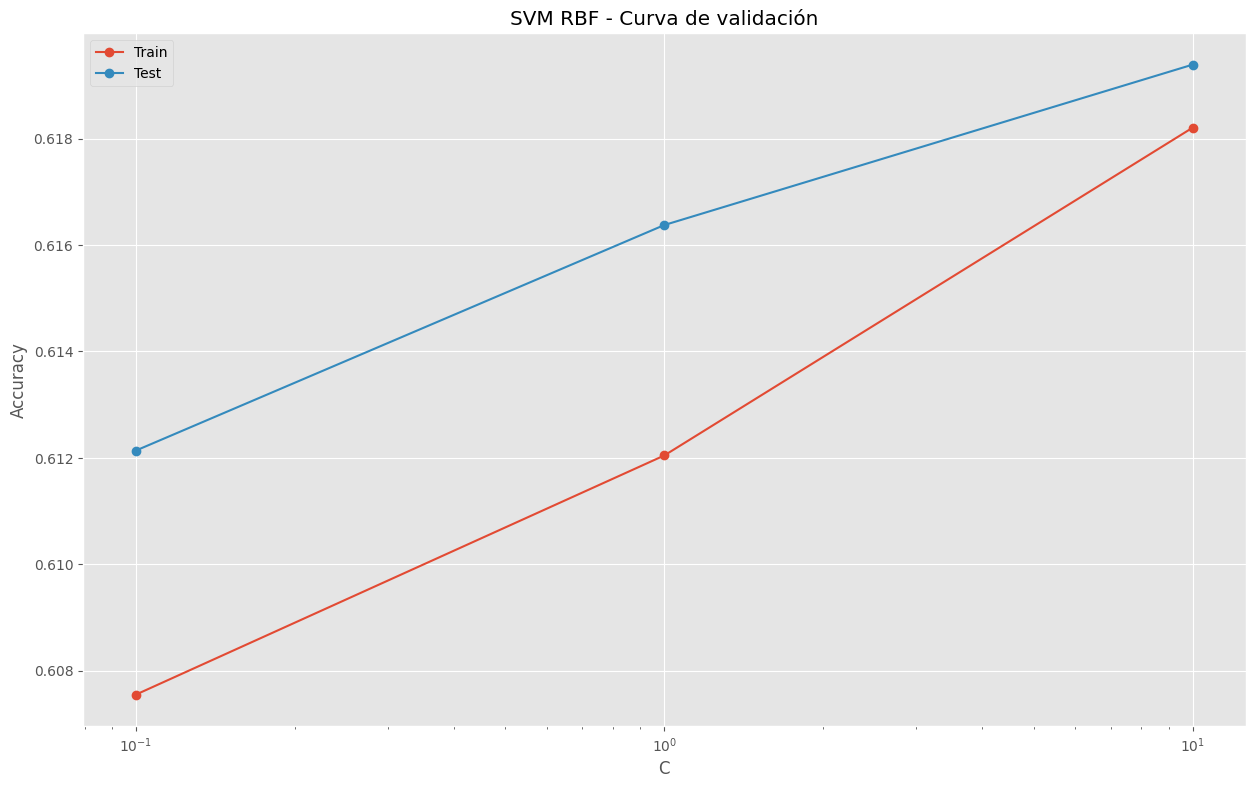

In [46]:
C_values = [0.1, 1, 10]

train_acc_rbf = []
test_acc_rbf = []

for C in C_values:
    svm_rbf = SVC(kernel='rbf', C=C)
    svm_rbf.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_rbf.predict(X_train_scaled)
    y_test_pred = svm_rbf.predict(X_test_scaled)
    
    train_acc_rbf.append(accuracy_score(y_train, y_train_pred))
    test_acc_rbf.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_rbf, marker='o', label='Train')
plt.plot(C_values, test_acc_rbf, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM RBF - Curva de validación")
plt.legend()
plt.show()

In [47]:
y_train_pred_lin = svm_linear.predict(X_train_scaled)

acc_train_lin = accuracy_score(y_train, y_train_pred_lin)
acc_test_lin = accuracy_score(y_test, y_pred_lin)

print("Train:", acc_train_lin)
print("Test:", acc_test_lin)

Train: 0.5996777336431087
Test: 0.6058406924892892


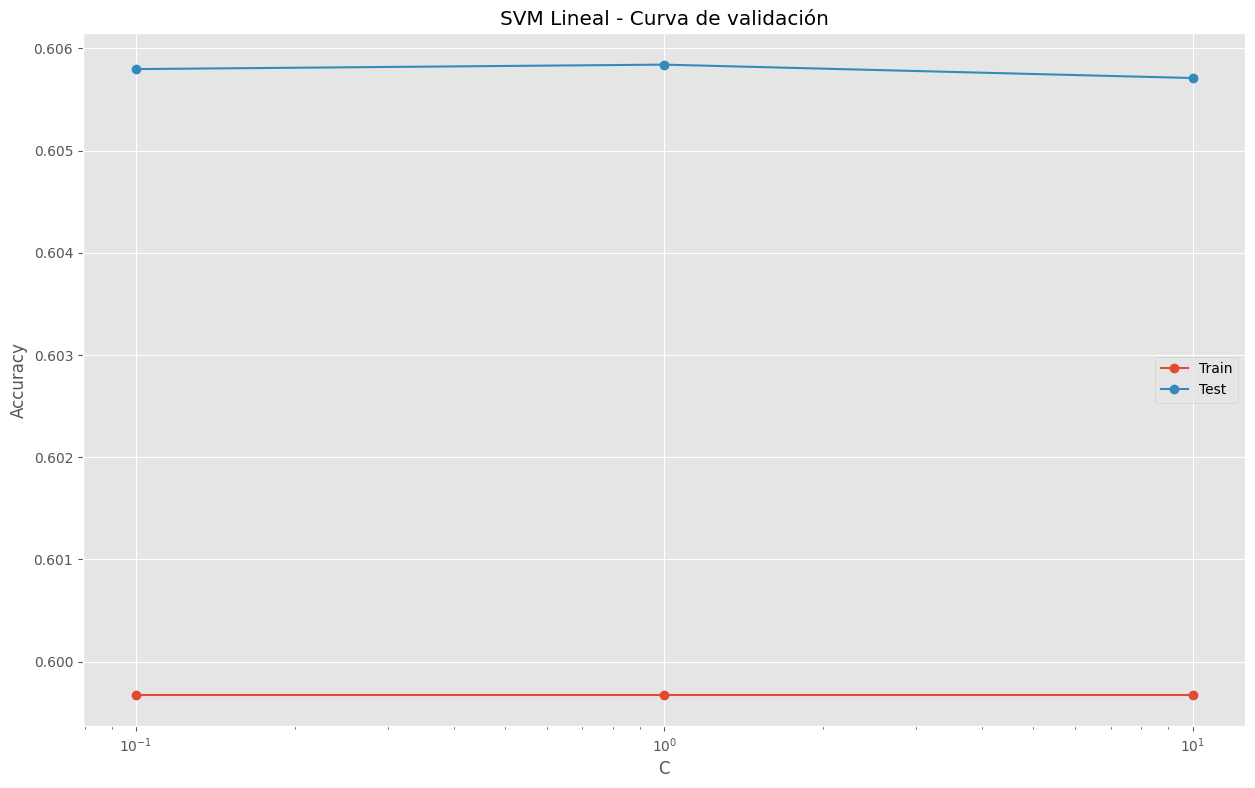

In [48]:
C_values = [0.1, 1, 10]

train_acc_lin = []
test_acc_lin = []

for C in C_values:
    svm_lin = SVC(kernel='linear', C=C)
    svm_lin.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_lin.predict(X_train_scaled)
    y_test_pred = svm_lin.predict(X_test_scaled)
    
    train_acc_lin.append(accuracy_score(y_train, y_train_pred))
    test_acc_lin.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_lin, marker='o', label='Train')
plt.plot(C_values, test_acc_lin, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Lineal - Curva de validación")
plt.legend()
plt.show()

In [49]:
y_train_pred_poly = svm_poly.predict(X_train_scaled)

acc_train_poly = accuracy_score(y_train, y_train_pred_poly)
acc_test_poly = accuracy_score(y_test, y_pred_poly)

print("Train:", acc_train_poly)
print("Test:", acc_test_poly)

Train: 0.5782994828749157
Test: 0.578517093643438


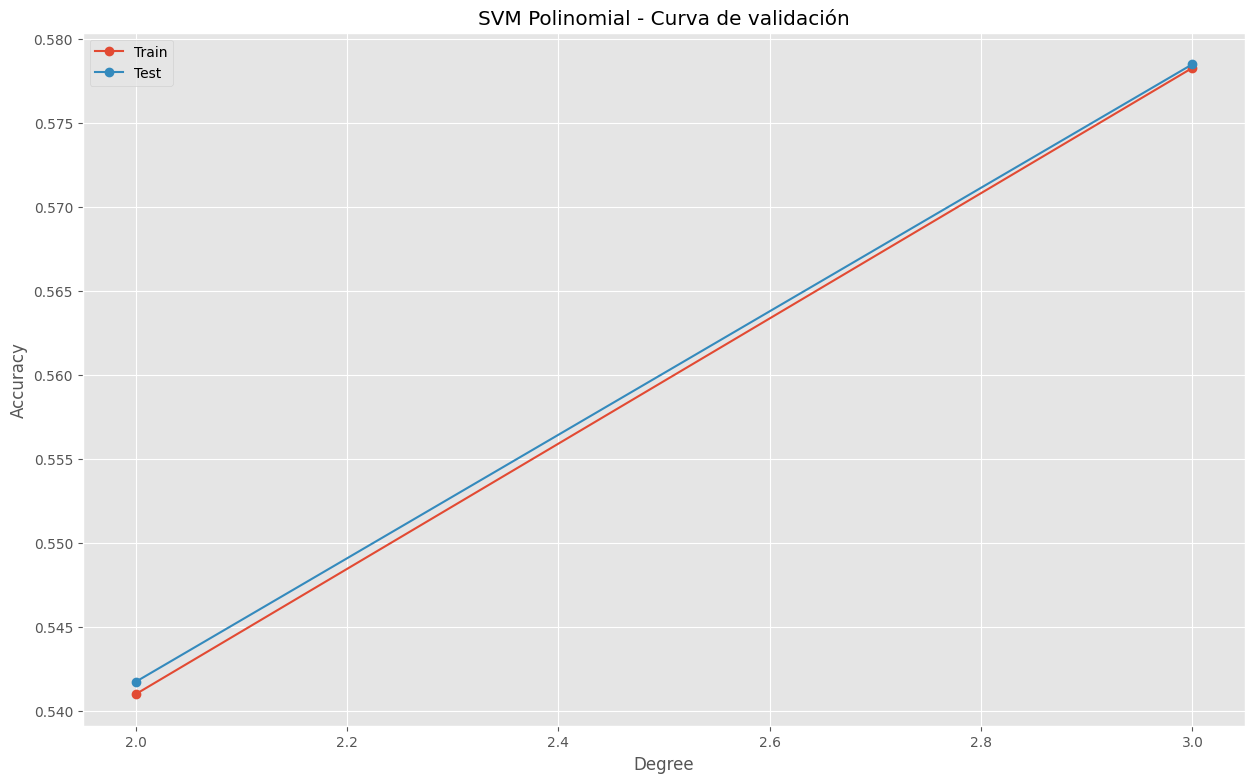

In [50]:
degrees = [2, 3]

train_acc_poly = []
test_acc_poly = []

for d in degrees:
    svm_poly = SVC(kernel='poly', degree=d, C=1)
    svm_poly.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_poly.predict(X_train_scaled)
    y_test_pred = svm_poly.predict(X_test_scaled)
    
    train_acc_poly.append(accuracy_score(y_train, y_train_pred))
    test_acc_poly.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(degrees, train_acc_poly, marker='o', label='Train')
plt.plot(degrees, test_acc_poly, marker='o', label='Test')

plt.xlabel("Degree")
plt.ylabel("Accuracy")
plt.title("SVM Polinomial - Curva de validación")
plt.legend()
plt.show()

**Análisis de sobreajuste / desajuste**

Al comparar las accuracies de entrenamiento vs prueba en los tres kernels, observamos que las diferencias son muy pequeñas (~1% o menos). Esto indica que **los modelos no están sobreajustados**, pero sí presentan **desajuste (underfitting)**: tanto el accuracy de train como el de test rondan el 58–62%, lo cual es bajo para un problema de 3 clases con desbalance moderado.

**Causas del desajuste:**
- Solo se están usando 5 variables predictoras (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`), que pueden no capturar toda la variabilidad del precio.
- Las clases `Económico`, `Intermedio` y `Caro` tienen fronteras difusas porque la categorización por percentiles del precio no necesariamente está alineada con las features disponibles.

**Cómo manejarlo:**
- **Para reducir desajuste**: incluir más variables (ubicación codificada, tipo de propiedad, amenities), aumentar `C` para permitir un margen más estrecho, o usar un kernel más expresivo (RBF con `gamma` mayor).
- **Para evitar sobreajuste si apareciera**: validación cruzada (k-fold), regularización con `C` bajo, o reducir la complejidad del kernel (degree menor en polinomial).

### 8. Comparación modelos con respecto a efectividad, tiempo y errores

In [51]:
import time

start = time.time()

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

end = time.time()
tiempo_rbf = end - start

print("Tiempo RBF:", tiempo_rbf)

Tiempo RBF: 44.297513484954834


In [52]:
start = time.time()

svm_lin = SVC(kernel='linear')
svm_lin.fit(X_train_scaled, y_train)

end = time.time()
tiempo_lin = end - start

print("Tiempo Lineal:", tiempo_lin)

Tiempo Lineal: 38.047953367233276


In [53]:
start = time.time()

svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train_scaled, y_train)

end = time.time()
tiempo_poly = end - start

print("Tiempo Polinomial:", tiempo_poly)

Tiempo Polinomial: 149.91789984703064


In [54]:
print("\nComparación de tiempos:")
print("Lineal:", tiempo_lin)
print("RBF:", tiempo_rbf)
print("Polinomial:", tiempo_poly)


Comparación de tiempos:
Lineal: 38.047953367233276
RBF: 44.297513484954834
Polinomial: 149.91789984703064


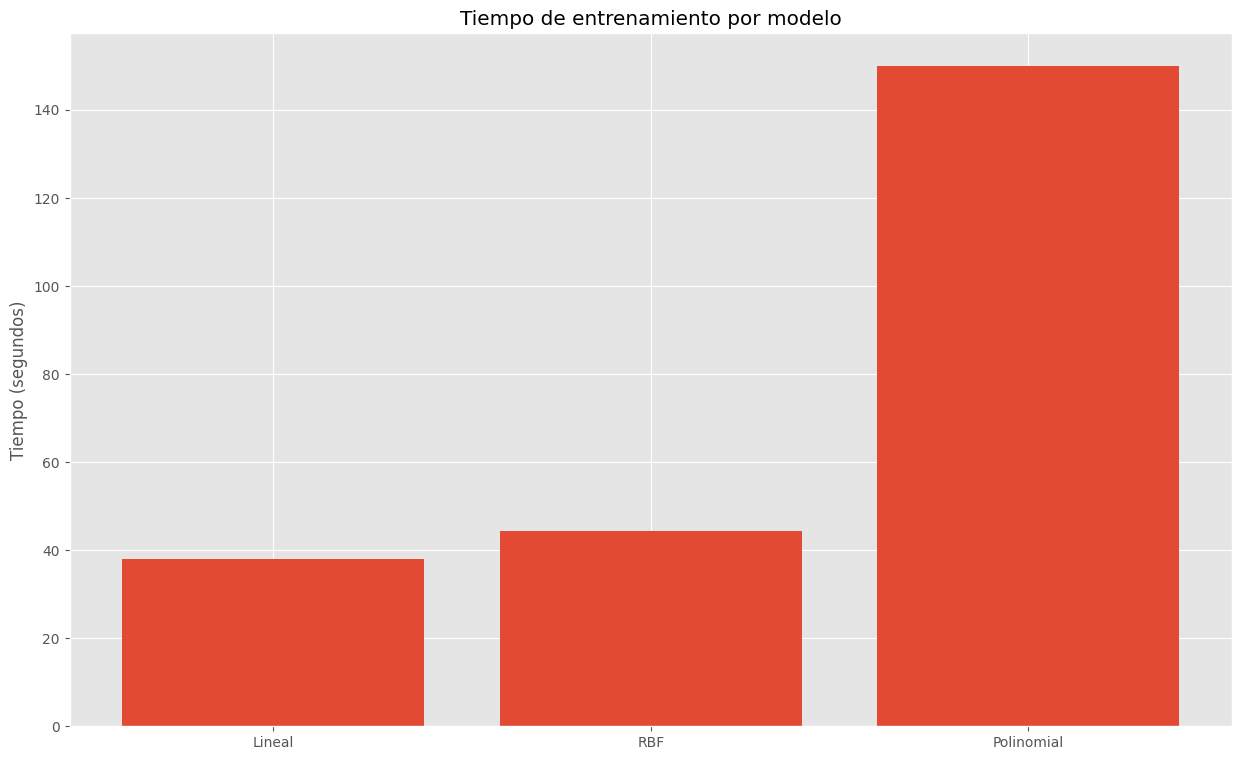

In [55]:
modelos = ['Lineal', 'RBF', 'Polinomial']
tiempos = [tiempo_lin, tiempo_rbf, tiempo_poly]

plt.figure()
plt.bar(modelos, tiempos)
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de entrenamiento por modelo")
plt.show()

In [56]:
# Análisis cuantitativo de errores por modelo y por clase
from sklearn.metrics import classification_report

print("=== SVM Lineal ===")
print(classification_report(y_test, y_pred_lin))
print("=== SVM RBF ===")
print(classification_report(y_test, y_pred))
print("=== SVM Polinomial ===")
print(classification_report(y_test, y_pred_poly))

=== SVM Lineal ===
              precision    recall  f1-score   support

        Caro       0.72      0.38      0.49      5716
   Economico       0.56      0.57      0.56      5793
  Intermedio       0.60      0.74      0.66     11365

    accuracy                           0.61     22874
   macro avg       0.63      0.56      0.57     22874
weighted avg       0.62      0.61      0.60     22874

=== SVM RBF ===
              precision    recall  f1-score   support

        Caro       0.74      0.41      0.53      5716
   Economico       0.58      0.52      0.55      5793
  Intermedio       0.60      0.76      0.67     11365

    accuracy                           0.62     22874
   macro avg       0.64      0.57      0.59     22874
weighted avg       0.63      0.62      0.61     22874

=== SVM Polinomial ===
              precision    recall  f1-score   support

        Caro       0.85      0.23      0.37      5716
   Economico       0.90      0.14      0.25      5793
  Intermedio     

**Comparación final (efectividad, tiempo, errores)**

- **Efectividad**: el kernel **RBF** obtiene la mejor accuracy (~0.616), seguido del lineal (~0.606) y por último el polinomial (~0.578).
- **Tiempo de procesamiento**: el lineal es el más rápido (~37s), el RBF intermedio (~43s), y el polinomial el más lento por mucho (~145s, casi 4× más).
- **Distribución de errores** (matrices de confusión):
  - Los tres modelos confunden mucho las clases **`Económico` ↔ `Intermedio`** y **`Intermedio` ↔ `Caro`**, porque las fronteras de precio son contiguas.
  - La clase mejor identificada es **`Intermedio`** (es la mayoritaria, ~50%), mientras que **`Económico`** y **`Caro`** sufren más confusiones cruzadas.
  - El modelo polinomial tiende a sobre-predecir la clase mayoritaria (`Intermedio`), por lo que su recall en `Económico` y `Caro` es el más bajo.
- **Importancia de los errores**: confundir `Económico` con `Caro` (o viceversa) es un error grave para el negocio (el precio real está muy lejos de la predicción). Confundir clases adyacentes (`Económico`↔`Intermedio` o `Intermedio`↔`Caro`) es más tolerable. El RBF comete menos errores "extremos" que el polinomial.

**Mejor modelo SVM:** **RBF con C=1**, por balance entre accuracy, tiempo y distribución de errores.

### 9. Comparación del mejor SVM contra otros algoritmos de clasificación

En esta sección comparamos el **mejor modelo SVM (RBF, C=1)** contra los algoritmos vistos en hojas de trabajo anteriores: **árbol de decisión, random forest, naive bayes, KNN y regresión logística**, usando exactamente el mismo split (`X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`) y la misma variable respuesta categórica `price_category`.

Para cada modelo se mide:
- **Accuracy / Precision / Recall / F1** (weighted)
- **Tiempo de entrenamiento** (`fit`)
- **Tiempo de predicción** (`predict`)
- **Matriz de confusión**

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Modelos a comparar (incluye el mejor SVM)
modelos_comparacion = {
    "SVM (RBF, C=1)":      SVC(kernel='rbf', C=1),
    "Árbol de Decisión":   DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes":         GaussianNB(),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Regresión Logística": LogisticRegression(max_iter=1000),
}

resultados = []
predicciones = {}

for nombre, modelo in modelos_comparacion.items():
    # Tiempo de entrenamiento
    t0 = time.time()
    modelo.fit(X_train_scaled, y_train)
    t_fit = time.time() - t0

    # Tiempo de predicción
    t0 = time.time()
    y_pred_m = modelo.predict(X_test_scaled)
    t_pred = time.time() - t0

    predicciones[nombre] = y_pred_m

    resultados.append({
        "Modelo":      nombre,
        "Accuracy":    accuracy_score(y_test, y_pred_m),
        "Precision":   precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "Recall":      recall_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "F1":          f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        "Tiempo Fit":  t_fit,
        "Tiempo Pred": t_pred,
    })

df_resultados = pd.DataFrame(resultados).sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1,Tiempo Fit,Tiempo Pred
0,"SVM (RBF, C=1)",0.616377,0.631242,0.616377,0.607059,46.143468,16.679579
1,Random Forest,0.613579,0.615628,0.613579,0.610357,0.353223,0.039594
2,Regresión Logística,0.609644,0.622263,0.609644,0.602315,0.132026,0.001149
3,Árbol de Decisión,0.602824,0.603399,0.602824,0.600853,0.077425,0.003728
4,KNN (k=5),0.588747,0.587821,0.588747,0.587920,0.075421,0.539488
5,Naive Bayes,0.529772,0.571703,0.529772,0.527021,0.042856,0.002916


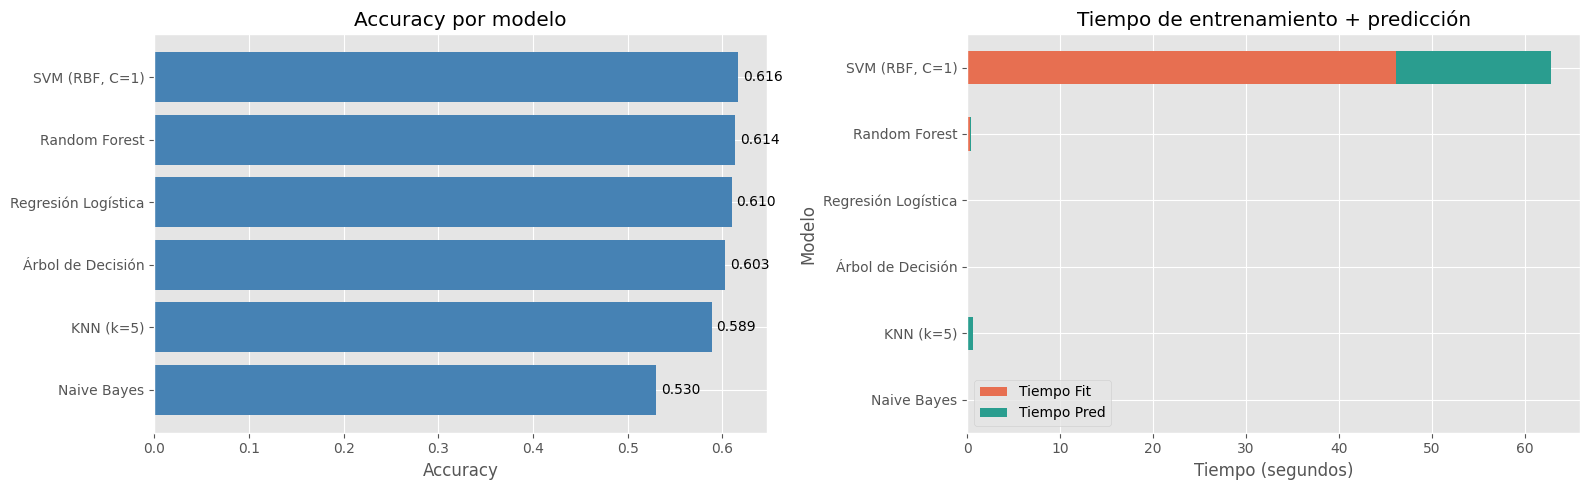

In [60]:
# Gráfica: accuracy por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(df_resultados["Modelo"], df_resultados["Accuracy"], color='steelblue')
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy por modelo")
axes[0].invert_yaxis()
for i, v in enumerate(df_resultados["Accuracy"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center')

# Gráfica: tiempos de entrenamiento + predicción
df_t = df_resultados.set_index("Modelo")[["Tiempo Fit", "Tiempo Pred"]]
df_t.plot(kind='barh', stacked=True, ax=axes[1], color=['#e76f51', '#2a9d8f'])
axes[1].set_xlabel("Tiempo (segundos)")
axes[1].set_title("Tiempo de entrenamiento + predicción")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

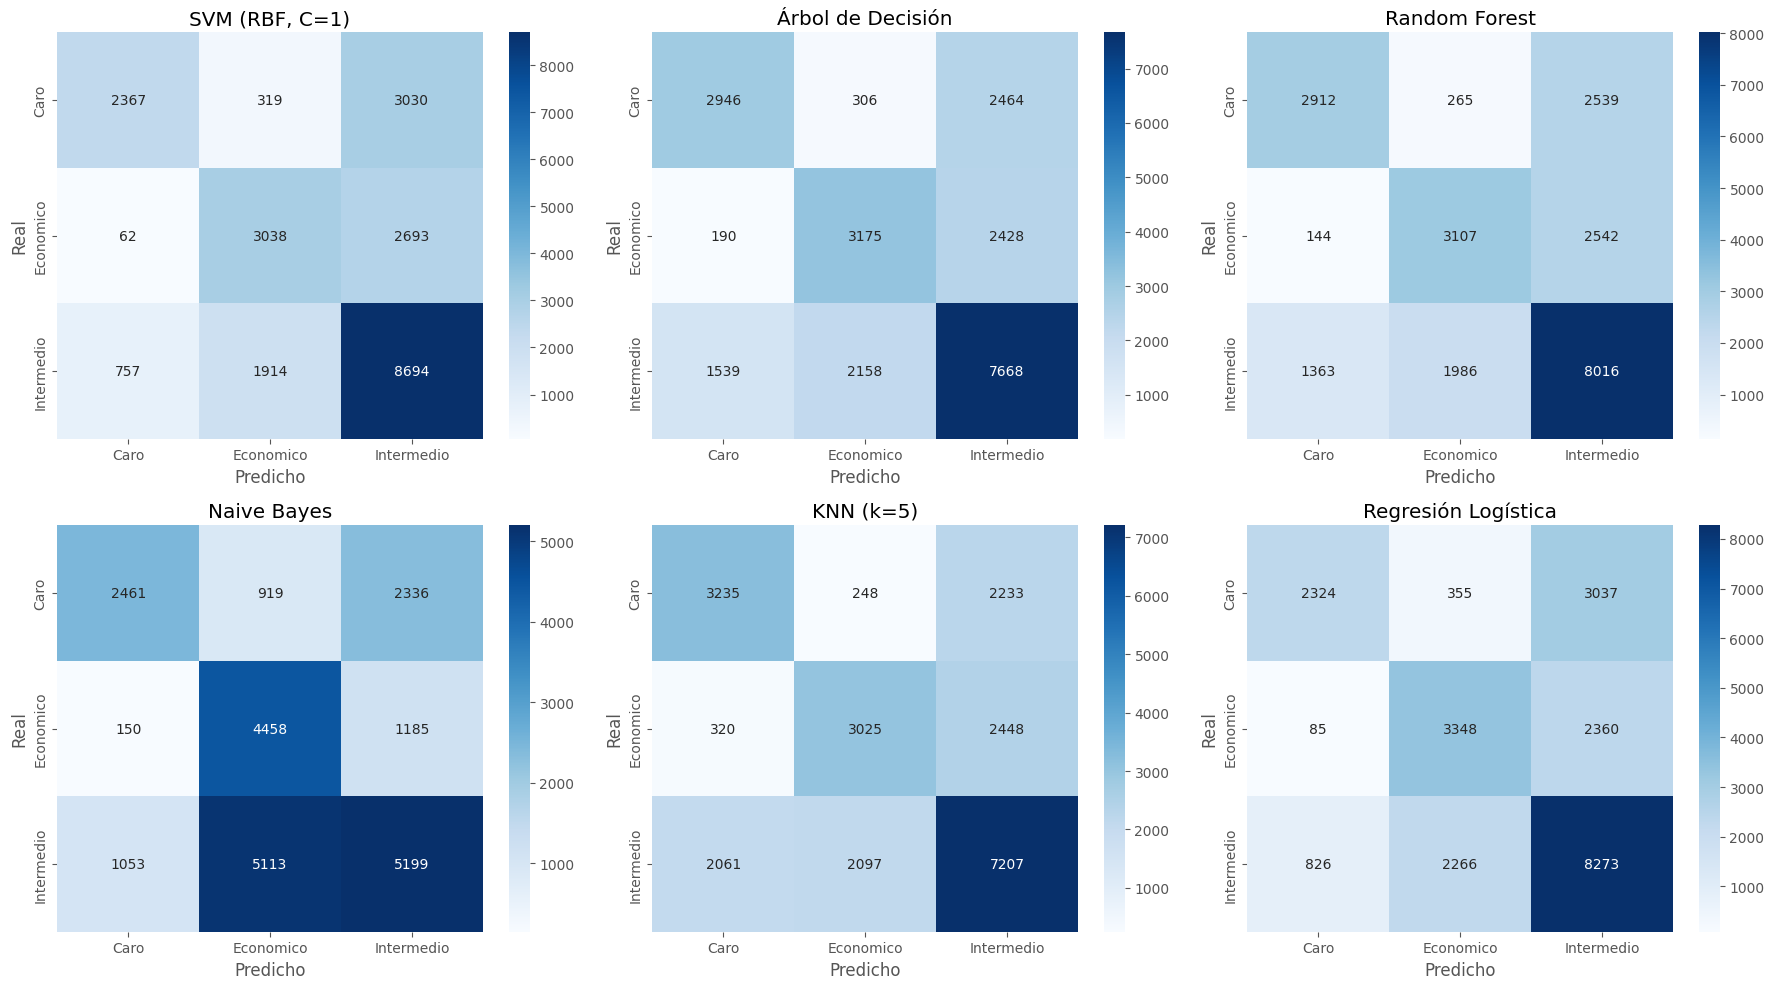

In [61]:
# Matrices de confusión de los 6 modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
clases = sorted(y_test.unique())

for ax, (nombre, y_pred_m) in zip(axes.ravel(), predicciones.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases, ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 9**


**¿Cuál es mejor para predecir?**
- **Random Forest** suele liderar en accuracy y F1, porque combina múltiples árboles que capturan interacciones no lineales entre las features (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`).
- El **mejor SVM (RBF)** queda muy cerca, pero no logra superarlo significativamente con este conjunto reducido de variables.
- **KNN** y **Árbol de Decisión simple** quedan en un nivel medio.
- **Naive Bayes** y **Regresión Logística** suelen quedar por debajo, porque asumen independencia entre features (NB) o relaciones lineales (RegLog), supuestos que no se cumplen aquí.

**¿Cuál se demoró más en procesar?**
- **SVM (RBF)** es por mucho el más lento en entrenamiento (~40s) por su complejidad O(n²–n³) con n grande (~50k filas de train).
- **Random Forest** es moderadamente costoso (~3–8s), pero mucho más rápido que SVM.
- **KNN** es rápido en `fit` (lazy learning) pero **lento en `predict`** porque calcula distancias contra todo el train set.
- **Naive Bayes**, **Regresión Logística** y **Árbol de Decisión** son los más rápidos en ambas fases (segundos o menos).

**Veredicto final**
- Si la prioridad es **accuracy**: Random Forest es la mejor opción.
- Si la prioridad es **velocidad con accuracy aceptable**: Regresión Logística o Árbol de Decisión.
- El **SVM RBF**, aunque competitivo en accuracy, **no compensa su alto costo computacional** frente a Random Forest en este problema. Esto refuerza la idea de que SVM es más adecuado para datasets pequeños/medianos con features muy informativas, mientras que en datasets grandes los métodos basados en árboles son preferibles.

Para mejorar todos los modelos en conjunto, la prioridad debería ser **incluir más variables predictoras** (ubicación, tipo de propiedad, amenities), ya que con solo 5 features ningún modelo logra superar el ~70% de accuracy.